In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/sample_data/foods_with_categories.csv")
df['Favored'] = df['Favored'].map({'Yes': 1, 'No': 0})

In [ ]:
X = df.drop(columns='Favored')
y = df['Favored']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.head(10)

,Food,Cuisine,Main_Protein,Cooking_Method,Vegetarian,Meal_Type,Favored
0,Slow Simmered Carnitas,Mexican,Pork,Simmered,No,Dinner,1
1,Ceviche Bar (Plated),Latin American,Seafood,Raw,No,Lunch,0
2,Creamy Chipotle Chicken Pasta,Mexican,Chicken,Simmered,No,Dinner,1
3,Chicken Pot Pie,American,Chicken,Baked,No,Dinner,0
4,Peruvian Lomo Saltado,Peruvian,Beef,Stir-Fried,No,Dinner,0
5,Classic Clam Chowder Bread Bowl,American,Seafood,Simmered,No,Lunch,1
6,Mediterranean Lamb Rice Bowl,Mediterranean,Lamb,Grilled,No,Lunch,0
7,Chicken Mole,Mexican,Chicken,Simmered,No,Dinner,0
8,Mommas Calabasitas Con Puerco,Mexican,Pork,Simmered,No,Dinner,0
9,Blackened Salmon,American,Fish,Grilled,No,Dinner,1


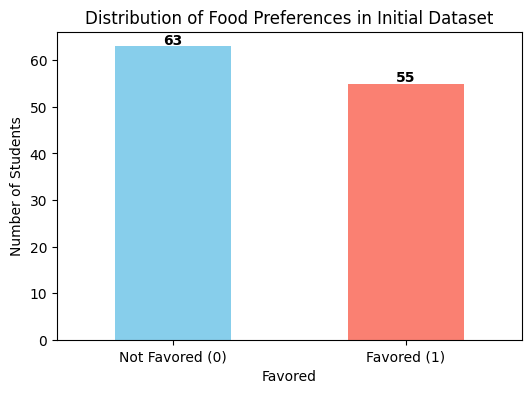

In [ ]:

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['skyblue','salmon'])

plt.xticks(ticks=[0,1], labels=['Not Favored (0)', 'Favored (1)'], rotation=0)
plt.ylabel('Number of Students')
plt.title('Distribution of Food Preferences in Initial Dataset')

for i, v in enumerate(class_counts):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.show()

In [ ]:
categorical_features = ['Cuisine', 'Main_Protein', 'Cooking_Method', 'Vegetarian', 'Meal_Type']

categorical_pipeline = Pipeline([
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
  ('cat', categorical_pipeline, categorical_features)
])

model = Pipeline([
  ('preprocessor', preprocessor),
  ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
  'classifier__n_estimators': [100, 200],
  'classifier__max_depth': [10, 20, None],
  'classifier__min_samples_split': [2, 5],
  'classifier__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
  model,
  param_grid,
  cv=5,
  scoring='accuracy',
  n_jobs=-1,
)

In [ ]:
grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

class_report = classification_report(y_test, y_pred)

print(f"Random Forest:\n {class_report}")

Random Forest:
               precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.83      0.71      0.77        14

    accuracy                           0.75        24
   macro avg       0.75      0.76      0.75        24
weighted avg       0.76      0.75      0.75        24



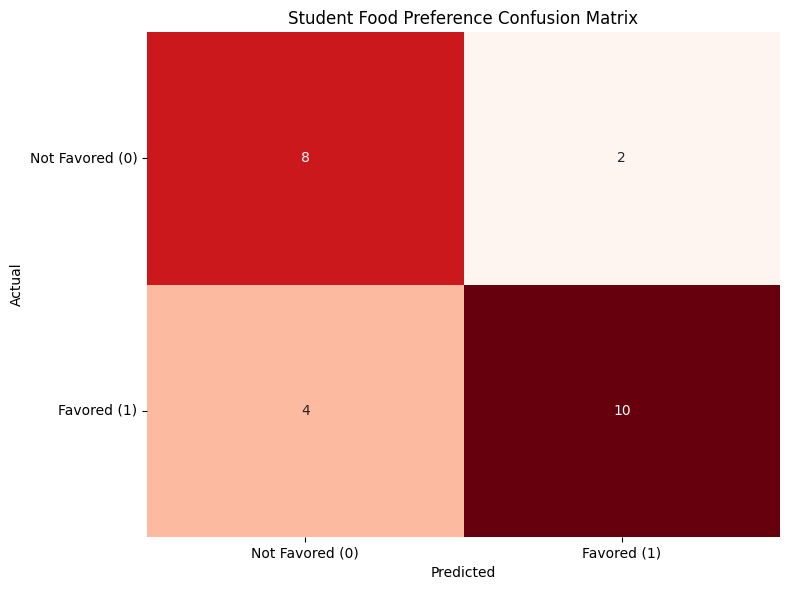

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)

ax.set_xticklabels(['Not Favored (0)', 'Favored (1)'])
ax.set_yticklabels(['Not Favored (0)', 'Favored (1)'], rotation=0)

ax.set_title('Student Food Preference Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

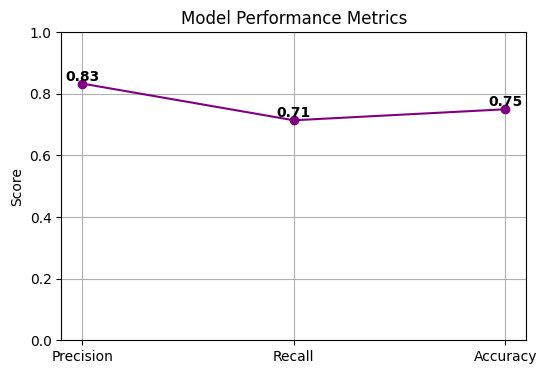

In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

metrics = {
    'Precision': precision,
    'Recall': recall,
    'Accuracy': accuracy
}

plt.figure(figsize=(6,4))
plt.plot(list(metrics.keys()), list(metrics.values()), marker='o', linestyle='-', color='purple')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Metrics')
plt.grid(True)

for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

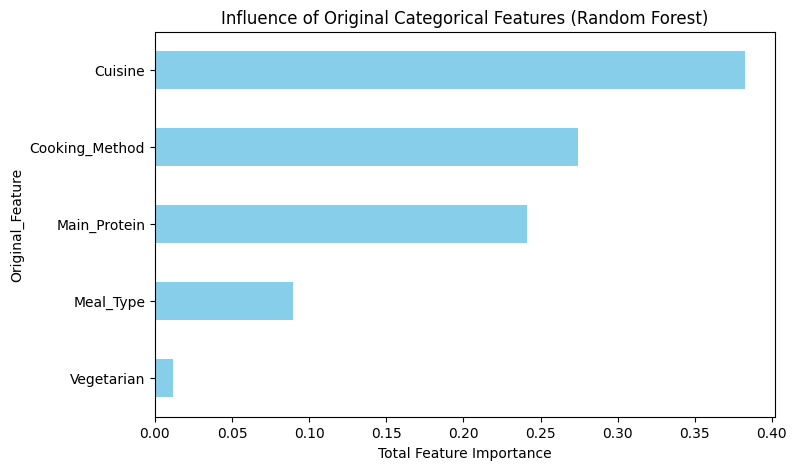

In [ ]:
best_model = grid_search.best_estimator_

rf = best_model.named_steps['classifier']

orig_features = best_model.named_steps['preprocessor'] \
    .named_transformers_['cat'].get_feature_names_out(categorical_features)

importances = rf.feature_importances_

feat_df = pd.DataFrame({'Feature': orig_features, 'Importance': importances})

def map_to_original(col_name):
    for feat in categorical_features:
        if col_name.startswith(feat):
            return feat
    return col_name

feat_df['Original_Feature'] = feat_df['Feature'].apply(map_to_original)

agg_importance = feat_df.groupby('Original_Feature')['Importance'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
agg_importance.plot(kind='barh', color='skyblue')
plt.xlabel('Total Feature Importance')
plt.title('Influence of Original Categorical Features (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
sample = pd.DataFrame([{
  'Food': 'Chicken Shawarma',
  'Cuisine': 'Mediterranean',
  'Main_Protein': 'Chicken',
  'Cooking_Method': 'Grilled',
  'Vegetarian': 'No',
  'Meal_Type': 'Lunch'
}])

pred = grid_search.predict(sample)
print("Predicted student preference (1=favored, 0=not favored):", pred[0])

Predicted student preference (1=favored, 0=not favored): 0
